# BNPL Capstone – Exploratory Data Analysis & Feature Engineering

### Initial Data Inspection

The dataset contains 1,348,099 observations and 40 features, providing a large and comprehensive foundation for modeling borrower default risk.

The data includes a mix of borrower characteristics, loan attributes, macroeconomic indicators, and complaint-based features, enabling a holistic analysis of both individual financial behavior and external economic conditions.


### Data Structure

The dataset consists of:
- 26 numerical features (e.g., loan amount, income, interest rate)
- 11 categorical features (e.g., credit grade, home ownership, loan purpose)
- 1 datetime feature (`issue_date`)

This variety of feature types will require different preprocessing techniques, including encoding for categorical variables and potential scaling for numerical features.


### Data Quality

The dataset is largely complete, with minimal missing values across most variables. However, several features exhibit missingness:

- `emp_length` (~78,550 missing)
- `mort_acc` (~50,030 missing)
- `pub_rec_bankruptcies`
- `revol_util`
- `dti`

These variables are important indicators of borrower financial health and will require careful handling during data preparation.


### Feature Composition

Key feature groups include:

- Loan features: loan amount, interest rate, installment  
- Borrower features: income, employment length, credit history  
- Macroeconomic features: unemployment rate, inflation proxy, consumer sentiment  
- Behavioral features: CFPB complaint counts  

This diverse feature set enables modeling of both borrower-level risk and broader economic influences, which may improve predictive performance.

## Load Merged Dataset
We begin by loading the combined BNPL modeling dataset, which integrates lending data, consumer complaints, and macroeconomic indicators. This dataset will be used for exploratory analysis and feature engineering.

Understanding the structure and size of the dataset is critical before proceeding with data preparation and modeling.

In [4]:
import pandas as pd

BASE = '.'

df = pd.read_parquet(f'{BASE}/data/processed/bnpl_modeling_dataset.parquet')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1348099, 40)


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,...,cpi_inflation_proxy,consumer_credit_revolving,consumer_loan_delinquency_rate,consumer_sentiment_index,credit_card_delinquency_rate,credit_card_interest_rate,personal_savings_rate,unemployment_rate,cfpb_complaint_count,cfpb_complaint_count_state
0,5000.0,5000.0,36 months,7.75,156.11,A,A3,10+ years,MORTGAGE,70000.0,...,248.859,768.53592,3.48,95.7,2.5,13.63,5.7,4.0,0.0,0.0
1,7500.0,7500.0,36 months,13.75,255.43,E,E2,< 1 year,OWN,22000.0,...,248.859,768.53592,3.48,95.7,2.5,13.63,5.7,4.0,0.0,0.0
2,6000.0,6000.0,36 months,10.59,195.28,C,C2,< 1 year,RENT,20000.0,...,248.859,768.53592,3.48,95.7,2.5,13.63,5.7,4.0,0.0,0.0
3,4400.0,4400.0,36 months,9.64,141.25,B,B4,2 years,MORTGAGE,30000.0,...,248.859,768.53592,3.48,95.7,2.5,13.63,5.7,4.0,0.0,0.0
4,1200.0,1200.0,36 months,9.01,38.17,B,B2,< 1 year,RENT,36000.0,...,248.859,768.53592,3.48,95.7,2.5,13.63,5.7,4.0,0.0,0.0


# Initial Data Inspection

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348099 entries, 0 to 1348098
Data columns (total 40 columns):
 #   Column                          Non-Null Count    Dtype         
---  ------                          --------------    -----         
 0   loan_amnt                       1348099 non-null  float64       
 1   funded_amnt                     1348099 non-null  float64       
 2   term                            1348099 non-null  object        
 3   int_rate                        1348099 non-null  float64       
 4   installment                     1348099 non-null  float64       
 5   grade                           1348099 non-null  object        
 6   sub_grade                       1348099 non-null  object        
 7   emp_length                      1269549 non-null  object        
 8   home_ownership                  1348099 non-null  object        
 9   annual_inc                      1348095 non-null  float64       
 10  verification_status             1348099 no

In [6]:
df.describe()

,loan_amnt,funded_amnt,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,open_acc,...,cpi_inflation_proxy,consumer_credit_revolving,consumer_loan_delinquency_rate,consumer_sentiment_index,credit_card_delinquency_rate,credit_card_interest_rate,personal_savings_rate,unemployment_rate,cfpb_complaint_count,cfpb_complaint_count_state
count,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06,1.348095e+06,1.347725e+06,1.348070e+06,1.348099e+06,1.348099e+06,1.348070e+06,...,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06
mean,1.440900e+04,1.440019e+04,1.324156e+01,4.377778e+02,7.623774e+04,1.827425e+01,3.176326e-01,6.961622e+02,7.001624e+02,1.159045e+01,...,2.489259e+02,7.691914e+02,3.470270e+00,9.581218e+01,2.500302e+00,1.364287e+01,5.718745e+00,3.997154e+00,6.840160e+01,3.515441e+00
min,5.000000e+02,5.000000e+02,5.310000e+00,4.930000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,6.100000e+02,6.140000e+02,0.000000e+00,...,2.488590e+02,7.685359e+02,2.830000e+00,9.570000e+01,2.500000e+00,1.363000e+01,5.700000e+00,3.700000e+00,0.000000e+00,0.000000e+00
25%,7.975000e+03,7.950000e+03,9.750000e+00,2.482800e+02,4.575000e+04,1.179000e+01,0.000000e+00,6.700000e+02,6.740000e+02,8.000000e+00,...,2.488590e+02,7.685359e+02,3.480000e+00,9.570000e+01,2.500000e+00,1.363000e+01,5.700000e+00,4.000000e+00,4.700000e+01,0.000000e+00
50%,1.200000e+04,1.200000e+04,1.274000e+01,3.750400e+02,6.500000e+04,1.761000e+01,0.000000e+00,6.900000e+02,6.940000e+02,1.100000e+01,...,2.488590e+02,7.685359e+02,3.480000e+00,9.570000e+01,2.500000e+00,1.363000e+01,5.700000e+00,4.000000e+00,7.500000e+01,2.000000e+00
75%,2.000000e+04,2.000000e+04,1.599000e+01,5.802200e+02,9.000000e+04,2.405000e+01,0.000000e+00,7.100000e+02,7.140000e+02,1.400000e+01,...,2.488590e+02,7.685359e+02,3.480000e+00,9.570000e+01,2.500000e+00,1.363000e+01,5.700000e+00,4.000000e+00,9.200000e+01,5.000000e+00
max,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,1.099920e+07,9.990000e+02,3.900000e+01,8.450000e+02,8.500000e+02,9.000000e+01,...,2.527720e+02,8.076801e+02,3.480000e+00,1.014000e+02,2.540000e+00,1.473000e+01,8.400000e+00,4.100000e+00,1.460000e+02,2.100000e+01
std,8.716138e+03,8.712250e+03,4.765685e+00,2.614972e+02,6.992274e+04,1.115549e+01,8.777443e-01,3.185079e+01,3.185143e+01,5.474680e+00,...,3.991266e-01,4.106263e+00,6.513773e-02,6.427780e-01,2.989549e-03,9.419704e-02,1.327040e-01,2.749532e-02,3.475015e+01,4.179163e+00


In [11]:
df.duplicated().sum()

np.int64(0)

No significant duplicate records were identified, indicating that the dataset is well-structured for analysis.

## Data Types and Categorical Features

We examine categorical variables to understand borrower characteristics and loan structure.

In [32]:
for col in ['term', 'grade', 'home_ownership']:
    print(f"\n{col.upper()}")
    print(df[col].value_counts())


TERM
term
36 months    1023206
60 months     324893
Name: count, dtype: int64

GRADE
grade
B    393102
C    382323
A    235193
D    201657
E     94192
F     32306
G      9326
Name: count, dtype: int64

HOME_OWNERSHIP
home_ownership
MORTGAGE    666852
RENT        535699
OWN         145027
ANY            286
OTHER          182
NONE            53
Name: count, dtype: int64


The analysis shows that the dataset includes several categorical variables related to borrower characteristics and loan structure, such as loan term, credit grade, and home ownership. Loan term distribution indicates that the majority of loans are 36-month terms, suggesting a preference for shorter repayment periods among borrowers. Credit grade distribution is concentrated in mid-tier grades (B and C), indicating that most borrowers fall within moderate credit risk categories. Home ownership distribution shows that most borrowers either have a mortgage or rent, while relatively few own their homes outright. This may reflect varying levels of financial stability across the population. Overall, these categorical variables are likely to be important predictors of default risk and will require appropriate encoding for use in machine learning models.

## Numerical Feature Distributions


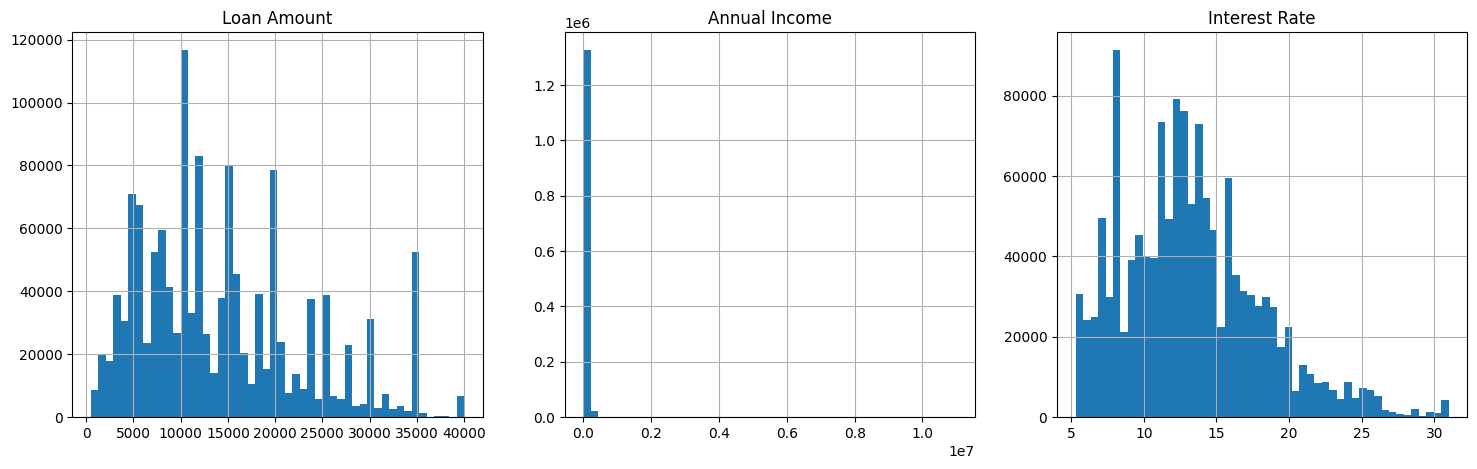

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

df['loan_amnt'].hist(ax=axes[0], bins=50)
axes[0].set_title("Loan Amount")

df['annual_inc'].hist(ax=axes[1], bins=50)
axes[1].set_title("Annual Income")

df['int_rate'].hist(ax=axes[2], bins=50)
axes[2].set_title("Interest Rate")

plt.show()

The distribution of loan amounts shows that most loans fall within the lower to mid-range, with fewer high-value loans. This suggests that the majority of borrowers request moderate loan sizes.
Annual income is highly right-skewed, with most borrowers earning lower to higher incomes and a small number of extreme high-income outliers. This indicates the need for potential transformation during modeling.
Interest rates appear to be normally distributed with a slight right skew, suggesting variability in borrower risk profiles.

### Outlier Detection 

In [18]:
df[['loan_amnt', 'annual_inc', 'dti']].describe()

,loan_amnt,annual_inc,dti
count,1.348099e+06,1.348095e+06,1.347725e+06
mean,1.440900e+04,7.623774e+04,1.827425e+01
std,8.716138e+03,6.992274e+04,1.115549e+01
min,5.000000e+02,0.000000e+00,-1.000000e+00
25%,7.975000e+03,4.575000e+04,1.179000e+01
50%,1.200000e+04,6.500000e+04,1.761000e+01
75%,2.000000e+04,9.000000e+04,2.405000e+01
max,4.000000e+04,1.099920e+07,9.990000e+02


The dataset contains significant outliers, particularly in annual income and debt-to-income (DTI) ratio. Extremely high income values and unusually large DTI values may distort model performance.
These outliers should be handled carefully during data preprocessing, either through transformation, capping, or removal.

## Correlation Analysis

We examine relationships between numerical variables to identify potential multicollinearity and predictive patterns.

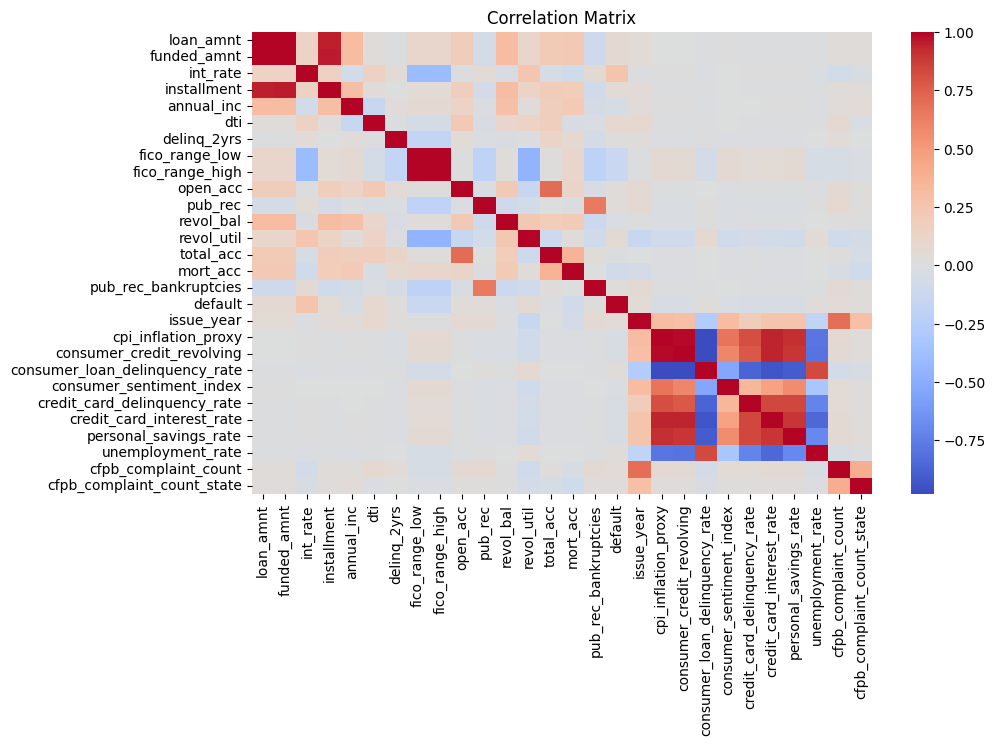

In [19]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Strong correlations are observed between loan amount, funded amount, and installment, which is expected since these variables are directly related. Macroeconomic variables such as interest rates, unemployment rate, and consumer indicators show relationships among themselves, indicating potential multicollinearity. The target variable (default) does not exhibit extremely strong linear correlations with individual features, suggesting that more complex models may be required to capture nonlinear relationships.

### Time-Based Exploration

In [27]:
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')

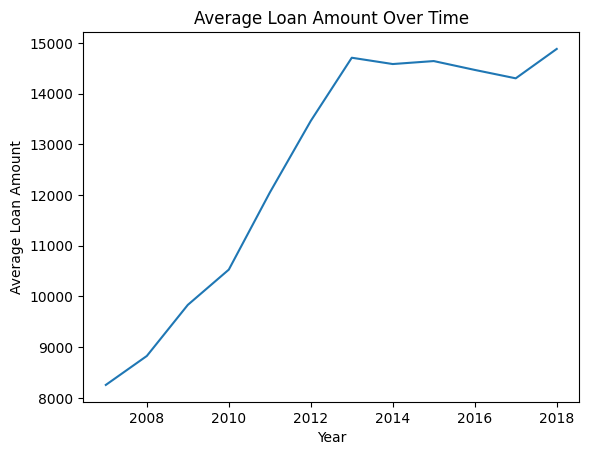

In [28]:
yearly_loans = df.groupby(df['issue_d'].dt.year)['loan_amnt'].mean()

yearly_loans.plot()
plt.title("Average Loan Amount Over Time")
plt.xlabel("Year")
plt.ylabel("Average Loan Amount")
plt.show()

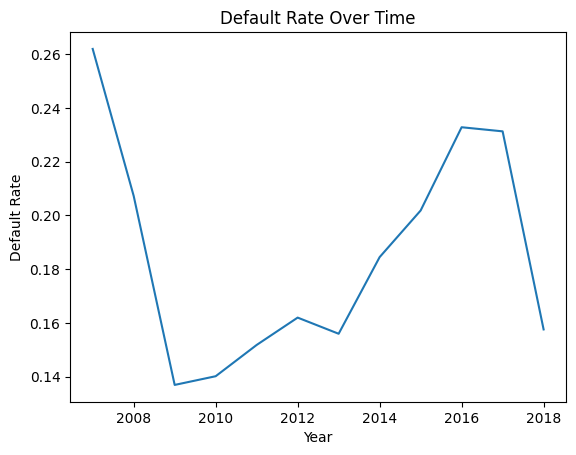

In [29]:
default_trend = df.groupby(df['issue_d'].dt.year)['default'].mean()

default_trend.plot()
plt.title("Default Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Default Rate")
plt.show()

The average loan amount has steadily increased over time, particularly between 2009 and 2013, suggesting a growth in lending activity and potentially increased borrower demand. After this period, loan amounts stabilize with slight fluctuations, indicating a more mature lending environment. The default rate shows a different pattern, with a sharp decline after 2007 followed by a gradual increase peaking around 2016–2017. This fluctuation may reflect changes in economic conditions, lending standards, or borrower risk profiles over time. The divergence between increasing loan amounts and fluctuating default rates suggests that both borrower behavior and external economic factors influence credit risk. These time-based trends indicate that temporal features may be valuable predictors in the modeling phase.

### Complaint Features

In [21]:
df['cfpb_complaint_count'].describe()

count    1.348099e+06
mean     6.840160e+01
std      3.475015e+01
min      0.000000e+00
25%      4.700000e+01
50%      7.500000e+01
75%      9.200000e+01
max      1.460000e+02
Name: cfpb_complaint_count, dtype: float64

In [22]:
df['cfpb_complaint_count_state'].describe()

count    1.348099e+06
mean     3.515441e+00
std      4.179163e+00
min      0.000000e+00
25%      0.000000e+00
50%      2.000000e+00
75%      5.000000e+00
max      2.100000e+01
Name: cfpb_complaint_count_state, dtype: float64

## Feature Relationships with Default

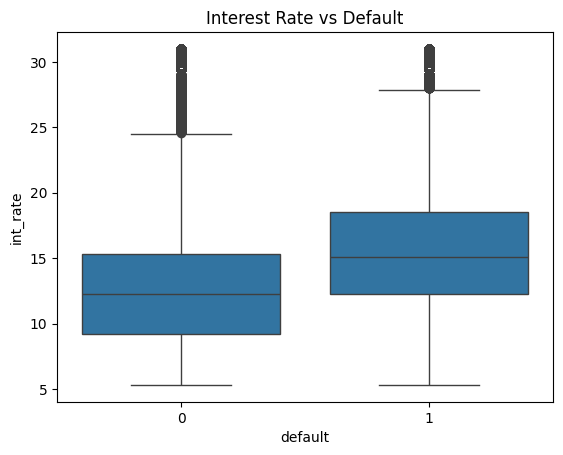

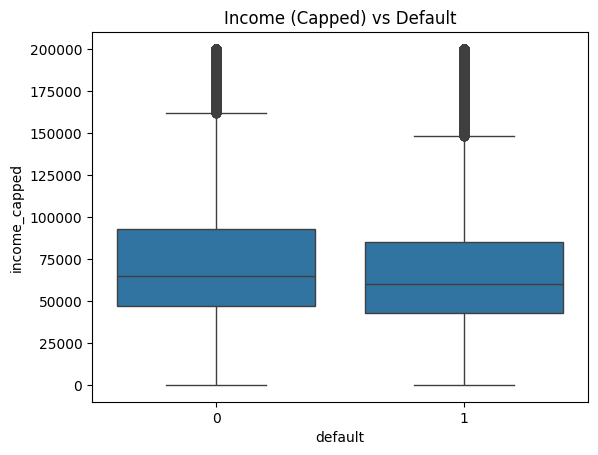

In [30]:
sns.boxplot(x='default', y='int_rate', data=df)
plt.title('Interest Rate vs Default')
plt.show()

df['income_capped'] = df['annual_inc'].clip(upper=200000)

sns.boxplot(x='default', y='income_capped', data=df)
plt.title('Income (Capped) vs Default')
plt.show()

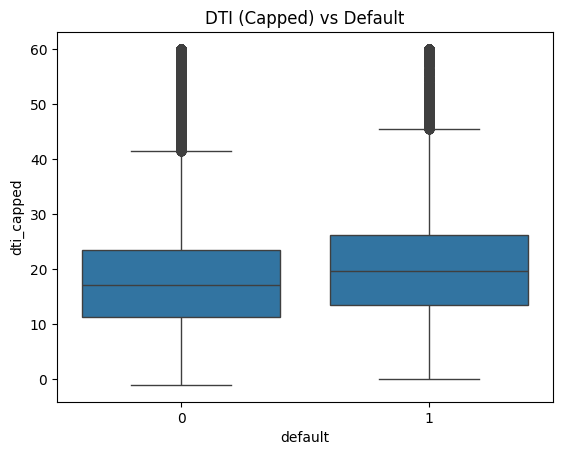

In [35]:
df['dti_capped'] = df['dti'].clip(upper=60)

sns.boxplot(x='default', y='dti_capped', data=df)
plt.title('DTI (Capped) vs Default')
plt.show()

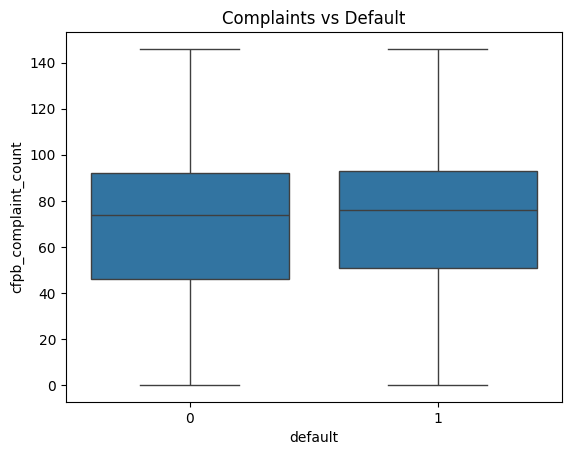

In [34]:
sns.boxplot(x='default', y='cfpb_complaint_count', data=df)
plt.title('Complaints vs Default')
plt.show()

The comparison of key financial and behavioral features against the target variable (default) reveals several important patterns in borrower risk. Interest rate shows the strongest and most distinct relationship with default. Borrowers who default have noticeably higher median interest rates and a clear upward shift in distribution. This reflects risk-based pricing, where higher-risk borrowers are assigned higher interest rates, making this a highly informative predictor of default. Income (after capping extreme values) shows a weaker relationship. Borrowers who default tend to have slightly lower median incomes; however, there is substantial overlap between the two groups. This indicates that income alone is not a strong predictor of default, though it may still provide value when combined with other financial indicators. Debt-to-income (DTI) ratio demonstrates a clearer relationship with default after handling outliers. Borrowers who default tend to have higher DTI values, indicating a greater financial burden relative to income. This suggests that DTI is an important predictor of default risk, as financially constrained borrowers are more likely to miss payments. Complaint-related features show a slight upward shift for borrowers who default, with marginally higher median complaint counts. While the difference is not as pronounced, this feature introduces a unique behavioral dimension, potentially capturing financial stress or dissatisfaction that may contribute to default risk. Overall, interest rate and DTI emerge as the strongest individual predictors of default, while income and complaint features provide additional context that may enhance predictive performance when used together in a multivariate model.

## EDA Summary

The exploratory data analysis identified several key patterns related to borrower default risk. Interest rate and debt-to-income (DTI) ratio emerged as the strongest predictors of default, with higher values clearly associated with increased likelihood of default. These features reflect borrower risk and financial burden, making them critical for modeling. Income showed a weaker relationship with default, with significant overlap between defaulted and non-defaulted borrowers. This suggests that income alone is not a strong predictor but may contribute when combined with other variables. Complaint-related features introduced a unique behavioral dimension, showing a slight increase for borrowers who default. While the relationship is less pronounced, these features may enhance model performance by capturing external signals of financial stress. Time-based analysis revealed changes in lending patterns and default rates over time, indicating that macroeconomic conditions may influence borrower behavior. Overall, the analysis highlights the importance of combining borrower-level, behavioral, and macroeconomic features to effectively predict default risk. These findings will guide the feature engineering and modeling process.

## Feature Engineering

To prepare the dataset for machine learning, several feature engineering and preprocessing steps were applied. These steps ensure that all variables are in a suitable format for modeling while preserving meaningful information related to borrower risk.

While some initial preprocessing was performed during the data collection phase, additional transformations are conducted here to optimize the dataset for predictive modeling.

### Cleaning and Transforming Variables

Certain variables were originally stored as text and required conversion into numerical format for modeling.

In [36]:
# Convert term to numeric
df['term'] = df['term'].str.replace(' months', '').astype(int)

# Clean emp_length
df['emp_length'] = df['emp_length'].str.replace('years', '')
df['emp_length'] = df['emp_length'].str.replace('year', '')
df['emp_length'] = df['emp_length'].str.replace('+', '')
df['emp_length'] = df['emp_length'].str.replace('< 1', '0')

df['emp_length'] = pd.to_numeric(df['emp_length'], errors='coerce')

### Handling Missing Values

Although the dataset is largely complete, several variables contain missing values that require imputation.

In [42]:
df['delinq_2yrs'] = df['delinq_2yrs'].fillna(0)
df['open_acc'] = df['open_acc'].fillna(df['open_acc'].median())
df['pub_rec'] = df['pub_rec'].fillna(0)
df['total_acc'] = df['total_acc'].fillna(df['total_acc'].median())

### Encoding Categorical Variables

Categorical variables must be converted into numerical format before being used in machine learning models.

In [44]:
# Drop unnecessary columns only if they exist
df = df.drop(columns=['issue_d', 'issue_date'], errors='ignore')

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

### Final Dataset Preparation

After completing all transformations, the dataset is fully numeric and ready for modeling.

In [45]:
print("Final dataset shape:", df.shape)
df.head()

Final dataset shape: (1348099, 284)


,loan_amnt,funded_amnt,term,int_rate,installment,emp_length,annual_inc,dti,delinq_2yrs,fico_range_low,...,issue_month_2018-03,issue_month_2018-04,issue_month_2018-05,issue_month_2018-06,issue_month_2018-07,issue_month_2018-08,issue_month_2018-09,issue_month_2018-10,issue_month_2018-11,issue_month_2018-12
0,5000.0,5000.0,36,7.75,156.11,10.0,70000.0,8.81,0.0,770.0,...,False,False,False,False,False,False,False,False,False,False
1,7500.0,7500.0,36,13.75,255.43,0.0,22000.0,14.29,1.0,660.0,...,False,False,False,False,False,False,False,False,False,False
2,6000.0,6000.0,36,10.59,195.28,0.0,20000.0,12.90,0.0,695.0,...,False,False,False,False,False,False,False,False,False,False
3,4400.0,4400.0,36,9.64,141.25,2.0,30000.0,3.72,0.0,695.0,...,False,False,False,False,False,False,False,False,False,False
4,1200.0,1200.0,36,9.01,38.17,0.0,36000.0,3.27,0.0,705.0,...,False,False,False,False,False,False,False,False,False,False
